# ANN and MLP Architecture

## Begin with several useful calculations

Imagine a greenhouse controller that receives soil dryness and air warmth. One neuron can combine those readings into one score. But we might want several intermediate signals: their combined level, whether dryness is larger than warmth, and whether warmth is larger than dryness.

A single score cannot give us all those quantities separately. We can give the same readings to several neurons, let each produce its own response, and then combine those responses in another stage.

Now we need a design. Which neurons receive the original readings? Which receive the intermediate responses? How many values should the final stage produce?

The **architecture** is that arrangement of computations and connections. It tells us how the pieces fit together before we choose the numerical values stored inside them.

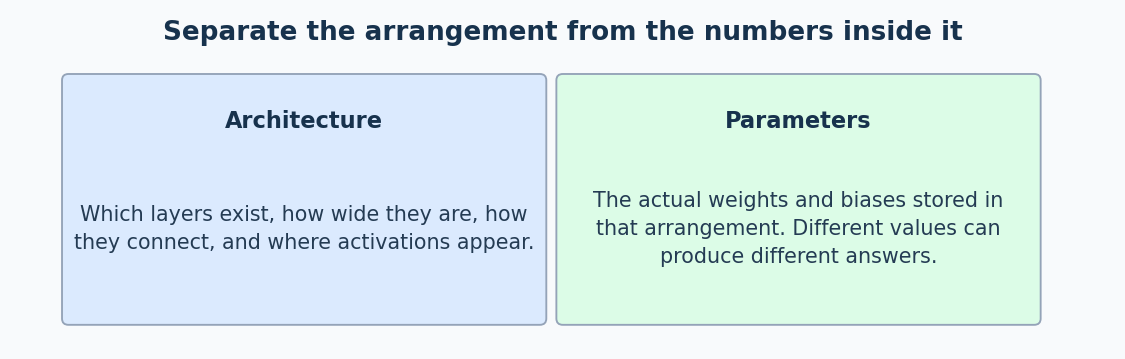

We will build one small design and follow actual numbers through it. The greenhouse readings and parameters are invented for easy arithmetic, not validated watering advice. The [code companion](04_ANN_and_MLP_Architecture.ipynb) constructs and inspects the same model in PyTorch.

## Start with the problem this lesson solves

A greenhouse decision may depend on several combinations of dryness and warmth, rather than one weighted total. A multilayer perceptron (MLP) places several neurons in a layer, then lets another layer combine their responses. An MLP is one kind of ANN.

An architecture specifies how many intermediate values are computed and how they connect. It creates room to learn useful combinations; choosing a larger architecture alone does not teach anything. We first inspect fixed weights so every hidden value has an explainable origin.

## Trace the complete 2 → 3 → 2 → 1 calculation

Use $x=[0.8,0.4]$. The first layer has three neurons with weight rows $[1,1]$, $[1,-1]$, and $[-1,1]$, and biases $[0,-0.5,0.25]$.

| First neuron | Weighted sum plus bias | After ReLU |
| --- | --- | --- |
| A | $0.8(1)+0.4(1)+0=1.2$ | 1.2 |
| B | $0.8(1)+0.4(-1)-0.5=-0.1$ | 0 |
| C | $0.8(-1)+0.4(1)+0.25=-0.15$ | 0 |

Thus the first representation is $h=[1.2,0,0]$. A combines readings; B and C compare them in different directions. These interpretations follow from the chosen weights, not from neuron names supplied to the model.

The second layer has two weight rows $[1,-1,0.5]$ and $[0.5,1,-1]$, with biases $[-0.2,0.1]$:

$$g_1=\max(0,1.2(1)+0(-1)+0(0.5)-0.2)=1.0,$$
$$g_2=\max(0,1.2(0.5)+0(1)+0(-1)+0.1)=0.7.$$

The last neuron uses weights $[2,-1]$ and bias $-0.5$:

$$z=1.0(2)+0.7(-1)-0.5=0.8.$$

This is the complete forward pass: two measurements become three features, then two features, then one score. A binary-probability interpretation would apply sigmoid, $1/(1+e^{-0.8})\approx0.689974$. The inspected model itself returns the raw score; it has not been trained as a calibrated classifier.

**Account for every adjustable number.** Layer one has $3\times2=6$ weights and three biases: nine parameters. Layer two has $2\times3=6$ weights and two biases: eight. The output has two weights and one bias: three. Total $9+8+3=20$. ReLU stores no adjustable weight. Sending seven examples through this model reuses these same 20 parameters; it does not create seven separate networks.

## Why use layers instead of one large sum?

Each nonlinear layer can reorganize information for the next. The network is useful when such learned combinations support predictions better than the original features alone. Backpropagation later adjusts every layer according to its effect on the final error; hidden layers usually do not receive their own hand-written targets.

Width gives a layer more intermediate values. Depth adds successive transformations. Both affect capacity and cost, and either can increase overfitting. Without nonlinear activations, the entire chain would reduce to a single affine map. The arithmetic above demonstrates the architecture, not an empirical advantage over a smaller model.

## Put several neurons beside each other

A neuron multiplies incoming values by weights, adds a bias, and applies an activation function. A **layer** groups several such computations operating on the same incoming description.

Let $x_1$ be dryness and $x_2$ warmth. Consider these three neurons:

| Unit | Score before activation | What the chosen calculation emphasizes |
| --- | --- | --- |
| A | $z_1=x_1+x_2$ | The combined level |
| B | $z_2=x_1-x_2-0.5$ | Dryness exceeding warmth by more than one half |
| C | $z_3=-x_1+x_2+0.25$ | Warmth relative to dryness, with an offset |

The symbols $z_1,z_2,z_3$ name the three scores. These are not three examples; they are three calculations for the same example.

Apply **ReLU** separately to each score. ReLU keeps a positive value and replaces a negative value by zero. The three resulting outputs become a new description of the original readings.

A **dense**, or fully connected, layer gives each output unit an adjustable weight for every input. Each unit also has its own bias. The units do not pass values sequentially to one another inside this ordinary layer; they receive the preceding layer’s values together.

Even if a learned weight happens to be zero, the connection is still an adjustable slot in the architecture.

## Give the whole network a clear name

**ANN** stands for artificial neural network. It is a broad name for models built from connected, parameterized computations. “Parameterized” means that numerical settings such as weights and biases determine the computation.

A **feedforward** network sends values from input toward output without a recurrent loop. An **MLP**, or multilayer perceptron, is a feedforward network built from dense layers, normally with nonlinear activations between them.

The historical word “perceptron” does not mean every modern MLP must use a hard step. Our network uses ReLU between dense layers.

| Term | What it tells us |
| --- | --- |
| ANN | The broad family of models |
| Feedforward | The direction of information flow has no recurrent loop |
| Dense layer | Every output unit has a weight for every incoming feature |
| MLP | A feedforward chain of dense layers with intermediate nonlinearities |

Without those nonlinearities, chained weighted sums and biases can collapse into one affine calculation. “Affine” means a weighted sum plus an offset. The activations allow the complete model to represent a more flexible function.

## Read a network picture from left to right

Our chosen network has sizes $2\to3\to2\to1$.

The first number means two input features. The next two numbers describe hidden layers with three and two units. The final number means one output score for each example.

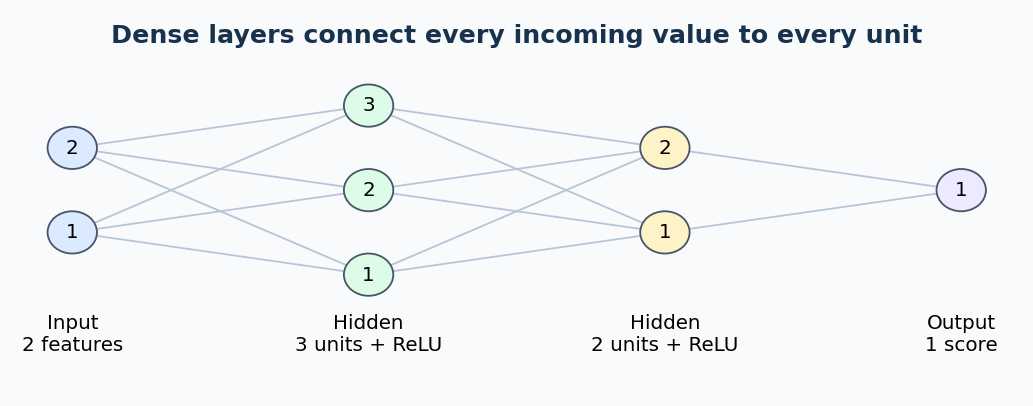

Each line represents a weight connecting one incoming value to one output unit. Biases are stored as well, although the picture leaves them out to keep the connections readable. Each hidden unit’s value is passed through ReLU before reaching the next layer.

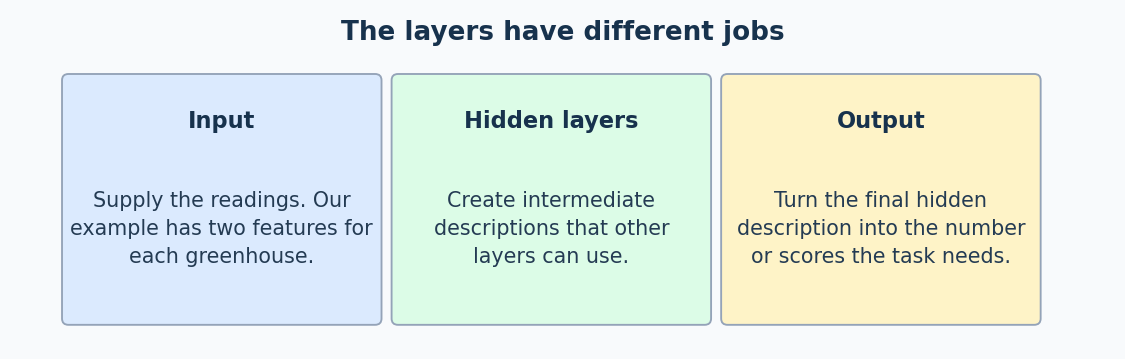

The **input layer** here means the supplied feature values; it has no learned parameters. A **hidden layer** produces intermediate values rather than the original input or final prediction. Hidden does not mean impossible to inspect. The **output layer** converts the last hidden description into the quantity the task asks for.

This model has two hidden layers and three parameterized layers. Different descriptions sometimes count depth differently, so stating both makes the design unambiguous.

## Follow one example into the first hidden layer

Use dryness $x_1=0.8$ and warmth $x_2=0.4$. Both readings use fixed scales from zero to one, with larger values meaning drier soil and warmer air.

Substitute those readings into the three chosen calculations:

| Unit | Multiply and add | Score | After ReLU |
| --- | --- | --- | --- |
| A | $0.8+0.4+0$ | 1.20 | 1.20 |
| B | $0.8-0.4-0.5$ | -0.10 | 0 |
| C | $-0.8+0.4+0.25$ | -0.15 | 0 |

For unit B, dryness minus warmth is $0.4$. Subtracting the bias threshold of $0.5$ gives $-0.1$, so ReLU returns zero. Unit A remains positive and passes its value onward.

The new description is therefore $h=(1.2,0,0)$. The letter $h$ names the hidden outputs, and $h_1,h_2,h_3$ identify their entries.

We began with two measurements and now have three intermediate values. The number of examples has not changed: this is still one greenhouse represented in a different way.

## Let the next layer combine what the first layer found

The second hidden layer receives $h$, not the original readings. Choose its two scores as

$$u_1=h_1-h_2+0.5h_3-0.2,$$
$$u_2=0.5h_1+h_2-h_3+0.1.$$

The letters $u_1,u_2$ name the new scores before activation. The coefficients are weights, and the final constants are biases.

| Unit | Substitute $h=(1.2,0,0)$ | Score | After ReLU |
| --- | --- | --- | --- |
| First | $1.2-0+0.5(0)-0.2$ | 1.0 | 1.0 |
| Second | $0.5(1.2)+0-0+0.1$ | 0.7 | 0.7 |

Both scores are positive. ReLU leaves them unchanged, giving $g=(1.0,0.7)$. The letter $g$ distinguishes this layer’s outputs from the earlier values $h$.

Finally, the output layer combines them into one score:

$$s=2g_1-g_2-0.5=2(1.0)-0.7-0.5=0.8.$$

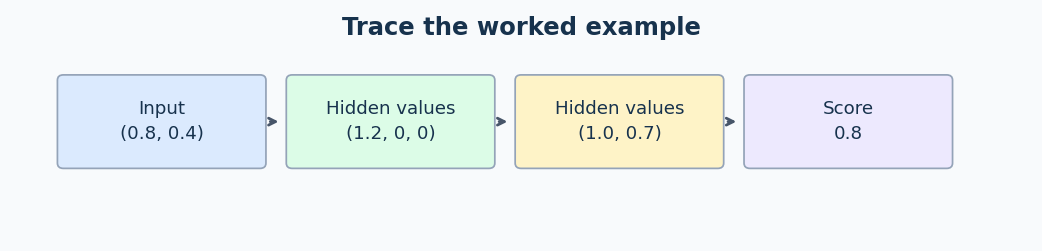

This is a **forward pass**: calculating an output using the currently stored parameters. No learning happened just because we moved through the layers.

Sigmoid could turn $0.8$ into about $0.690$, but that would not establish a meaningful watering probability. We chose all the parameters for arithmetic rather than learning or validating them on a real task.

## Make the pieces fit when several examples arrive

A **batch** is a group of examples processed together. A **tensor** is an array of numbers, and its **shape** lists the lengths of its axes.

For four greenhouse examples, the input is a table shaped `(4, 2)`: four rows, two features per row. The first layer produces `(4, 3)`, the second `(4, 2)`, and the output `(4, 1)`.

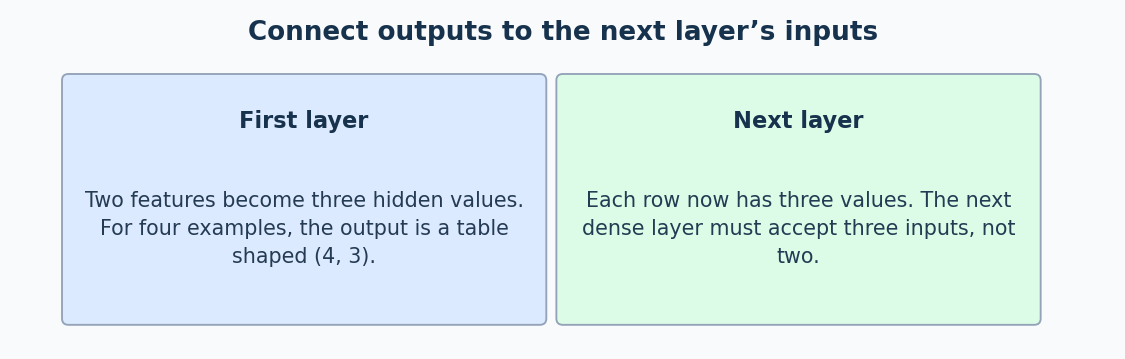

More generally, let $B$ be the batch size:

| Stage | Input values per example | Output table shape |
| --- | --- | --- |
| Original readings | Two | $(B,2)$ |
| First dense layer and ReLU | Two | $(B,3)$ |
| Second dense layer and ReLU | Three | $(B,2)$ |
| Output layer | Two | $(B,1)$ |

The first dimension keeps identifying examples. The second follows the changing description of each example. ReLU changes the values but preserves the shape.

A common construction mistake is connecting `Linear(2, 3)` to `Linear(2, 1)`. The first produces three values per example, so the next must accept three, not two.

## Understand where the weight matrices fit

PyTorch stores a dense layer’s weights as a table with one output unit per row. If a layer has $m$ input values and $n$ output units, its weight shape is $(n,m)$ and its bias shape is $(n,)$.

For incoming table $H$, the calculation is

$$Z=HW^T+b.$$

| Symbol | Meaning |
| --- | --- |
| $H$ | Incoming values, one example per row |
| $W$ | Weight matrix, one output unit’s weights per row |
| $T$ | Transpose: exchange rows and columns |
| $b$ | One bias per output unit, reused for each example |
| $Z$ | Scores before activation |

At the first layer, $H$ is simply the input table. The transpose gives the orientation needed for matrix multiplication: $(B,m)@(m,n)$ produces $(B,n)$.

For our model, the weight shapes are `(3, 2)`, `(2, 3)`, and `(1, 2)`. These shapes describe parameters, not the number of examples. Sending a larger batch does not enlarge the weight matrices.

## Count the adjustable values rather than guessing the size

Every output unit in a dense layer receives one weight per input. With $m$ inputs and $n$ outputs, that makes $mn$ weights. Adding one bias for each output contributes another $n$:

$$P=mn+n=(m+1)n.$$

$P$ means the parameter count. For our first layer, each of three units receives two weights and one bias. That is three parameters per unit, or nine altogether.

| Layer | Weights | Biases | Total |
| --- | --- | --- | --- |
| $2\to3$ | $2\times3=6$ | 3 | 9 |
| $3\to2$ | $3\times2=6$ | 2 | 8 |
| $2\to1$ | $2\times1=2$ | 1 | 3 |
| Whole network | 14 | 6 | **20** |

The two ReLU modules add no learned parameters. Turning off bias removes its contribution, leaving $mn$. A parameter slot still counts when its current numerical value is zero.

With a thirty-two-bit floating-point representation, each value uses four bytes, so these twenty numerical parameter values occupy eighty bytes. The actual program needs more memory for tensor objects, intermediate values, gradients, and possibly optimizer state. Parameter count is useful, but it is not a complete memory or runtime measurement.

## Separate width, depth, and batch size

These three quantities can all become larger, but they change different parts of the computation.

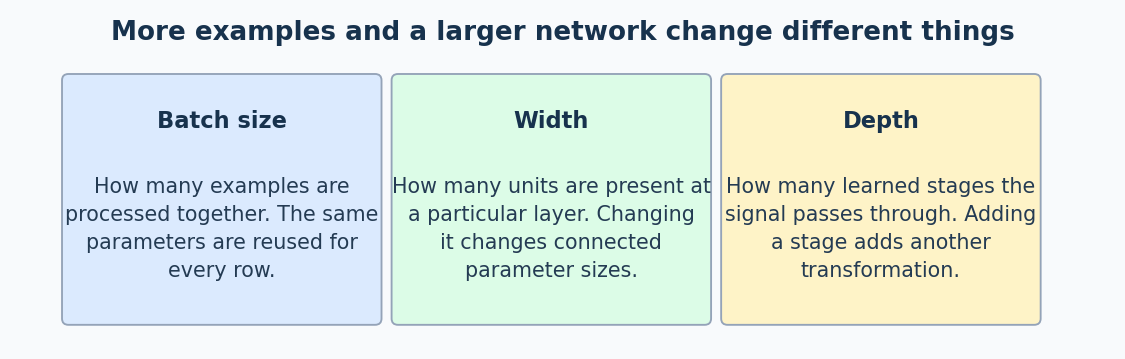

A wider layer provides more intermediate quantities. A deeper model adds stages that can transform those quantities again. A larger batch processes more examples using the same parameters.

| Architecture | Hidden layers | Learned parameters |
| --- | --- | --- |
| $2\to1$ | None | 3 |
| $2\to4\to1$ | One | 17 |
| $2\to8\to1$ | One | 33 |
| $2\to4\to4\to1$ | Two | 37 |

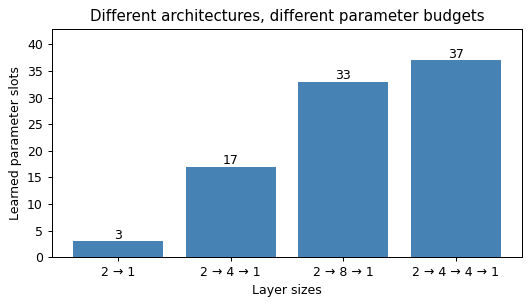

This chart compares size, not prediction quality. **Capacity** describes the range of functions a model can represent; parameter count is only one rough indicator of it.

A narrow hidden layer can be a **bottleneck**, requiring later layers to work from fewer values. That can discard useful information, but a smaller description may also be sufficient. The number of units alone does not tell us what information survived.

## Choose the final layer from the answer we need

The hidden width is a design choice. The output must agree with the target. If we want one temperature, one numerical output may be appropriate. If we want one of several classes, we usually need a score for each competing class.

| Task | Output shape for batch size $B$ | Interpretation |
| --- | --- | --- |
| One unrestricted number | $(B,1)$ | A regression value |
| One binary label using one score | $(B,1)$ | A binary logit |
| Exactly one of $K$ classes | $(B,K)$ | Competing class logits |
| Several independently possible labels | $(B,K)$ | Separate binary logits |
| Two continuous measurements | $(B,2)$ | Two regression values |

$K$ is the number of classes or labels. A **logit** is a raw classification score before conversion to a probability. Two tasks can have the same output shape but require different interpretations and losses.

The final mapping is often called an **output head**. It turns the last hidden description into the values needed by a task.

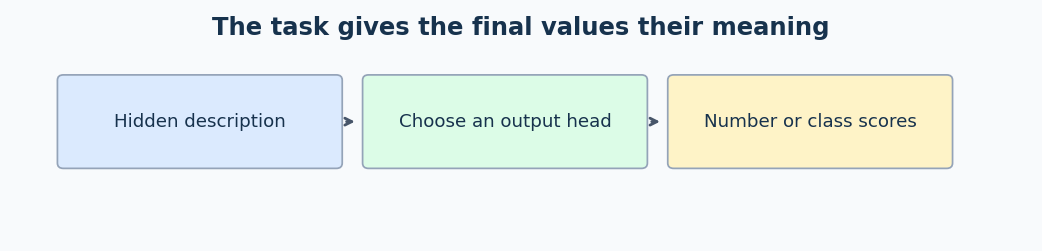

For classification losses that expect logits, keep the raw scores in the model output. Sigmoid can display binary probability estimates, while softmax makes competing class scores sum to one. Those transformations must match the task; they are not automatically part of every output layer.

## Express the same design in readable code

PyTorch offers two useful ways to describe this architecture:

| Form | How to read it | Why use it? |
| --- | --- | --- |
| `nn.Sequential` | Pass each module’s output to the next | A clear, simple chain |
| An `nn.Module` subclass with `forward` | Name the layers and write the path explicitly | Inspect intermediate values or describe more complex connections |

The companion creates both forms and copies the same parameters between them. Their outputs agree because both the arrangement and stored values match.

Two models with the same architecture need not give the same answer when their weights differ. Likewise, a random initialization supplies starting numbers; it is not a trained predictor.

`model.eval()` selects evaluation behavior for modules that distinguish training and evaluation. Our dense/ReLU model has no such behavior change. `torch.no_grad()` separately prevents operations from being recorded for gradient calculation. Neither command teaches the model or changes its architecture.

## Judge an architecture by more than how large it looks

An MLP is useful for fixed-size feature vectors and can be a component inside a larger system. But dense connections do not automatically exploit spatial neighborhoods in images or the order of a sequence.

For example, a color image measuring thirty-two by thirty-two pixels has three color channels: red, green, and blue. Flattening it creates $32\times32\times3=3072$ input values. Connecting those to a hundred and twenty-eight dense units needs $(3072+1)128=393344$ parameters in that layer alone.

That calculation explains why the connection pattern matters, not just the presence of neurons. A design can become expensive before it has learned anything useful.

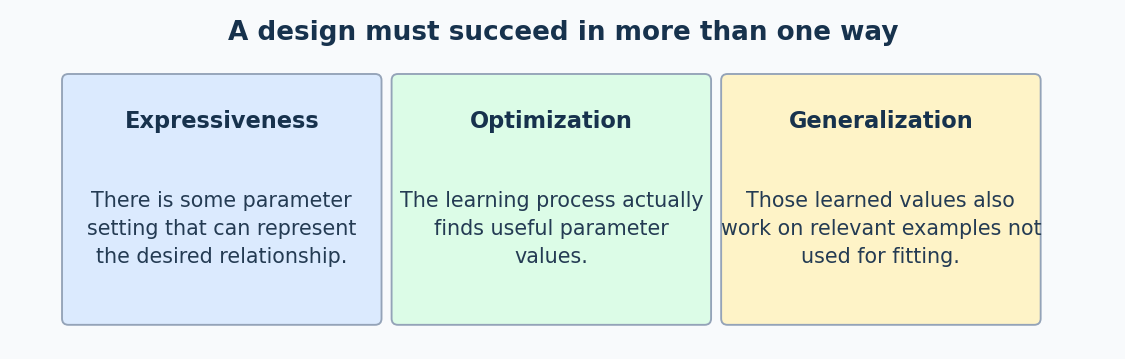

A larger network may represent more possibilities, yet be harder to fit, more expensive to run, or more likely to overfit. Architecture choices should be compared with validation data, leaving the test set for the final evaluation.

Our worked model demonstrates how the layers connect and compute. Its twenty parameters produce a traceable score. Whether an architecture solves a real problem depends on the task, the data, the learned parameter values, and the evidence from evaluation.

## Initialize layers without making hidden copies

If all hidden weights and biases begin at zero, hidden units produce identical outputs and receive identical hidden-weight gradients, so updates cannot give them different jobs. Zero initialization is acceptable for a convex linear model, and zero biases are commonly fine; the symmetry problem concerns repeated hidden units with identical incoming and outgoing structure.

The scale matters too. Xavier/Glorot normal initialization uses variance $2/(fan_{in}+fan_{out})$ and is a common choice for tanh-like layers. He/Kaiming normal uses variance $2/fan_{in}$ for ReLU. Tiny scales can shrink signals through depth; huge scales can enlarge them or saturate bounded activations.

## Normalize intermediate values by a defined group

Input standardization uses training-set feature statistics. BatchNorm normalizes each feature across the current batch in training mode and uses running statistics in evaluation mode. LayerNorm normalizes features within each example in both modes. Learned scale and offset mean the final output need not remain exactly standardized. The grouping axis is the essential difference.